<a href="https://colab.research.google.com/github/sarahibadi/Adult_Census-/blob/main/Adult_Cenus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(48842, 15)
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


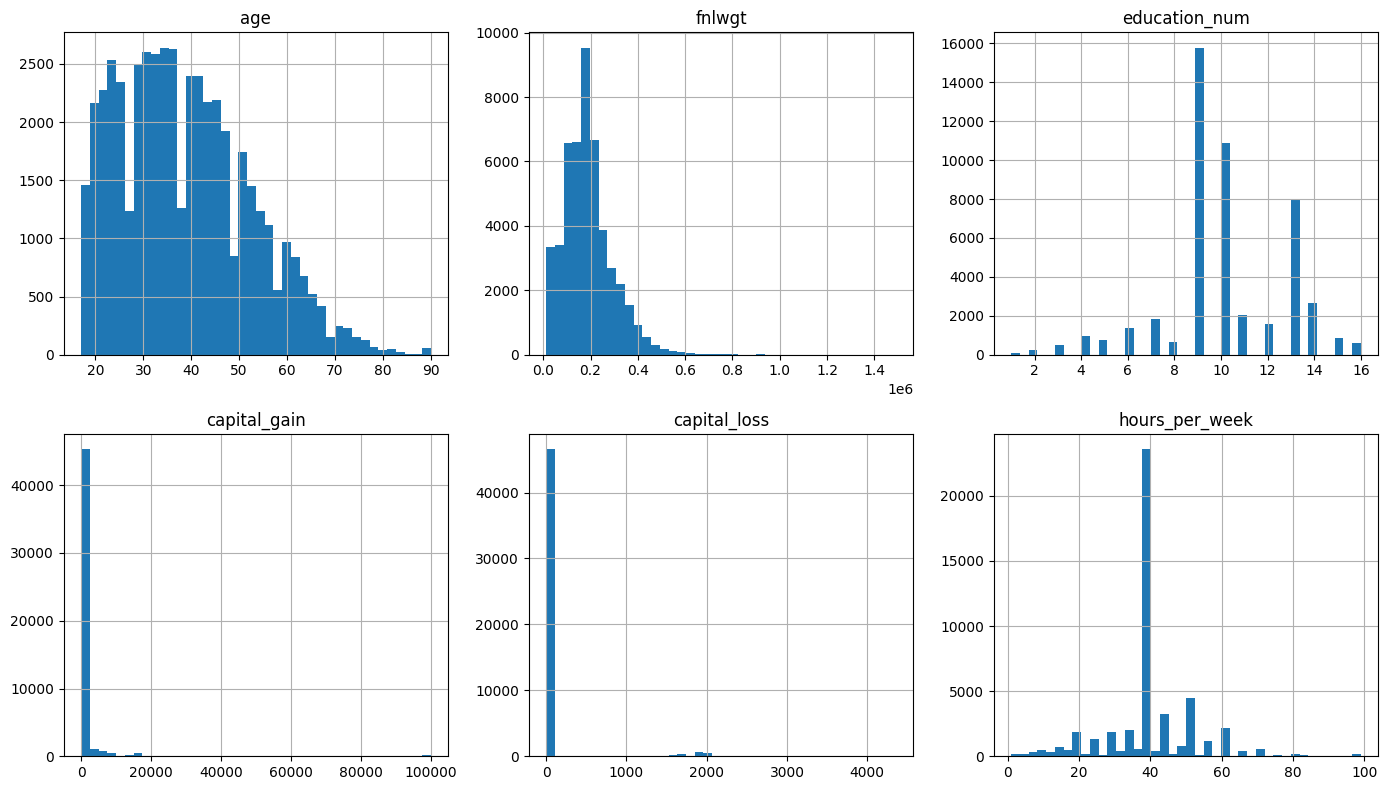


Income rate by education (top 10):
 education
Prof-school     0.739808
Doctorate       0.725589
Masters         0.549116
Bachelors       0.412835
Assoc-acdm      0.257964
Assoc-voc       0.253275
Some-college    0.189649
HS-grad         0.158578
12th            0.073059
7th-8th         0.064921
Name: income_num, dtype: float64

Income rate by marital_status (top 10):
 marital_status
Married-civ-spouse       0.446133
Married-AF-spouse        0.378378
Divorced                 0.101161
Married-spouse-absent    0.092357
Widowed                  0.084321
Separated                0.064706
Never-married            0.045480
Name: income_num, dtype: float64

Income rate by occupation (top 10):
 occupation
Exec-managerial      0.477818
Prof-specialty       0.451069
Armed-Forces         0.333333
Protective-serv      0.313327
Tech-support         0.290456
Sales                0.267987
Craft-repair         0.226276
Transport-moving     0.204246
Adm-clerical         0.136874
Machine-op-inspct    0.

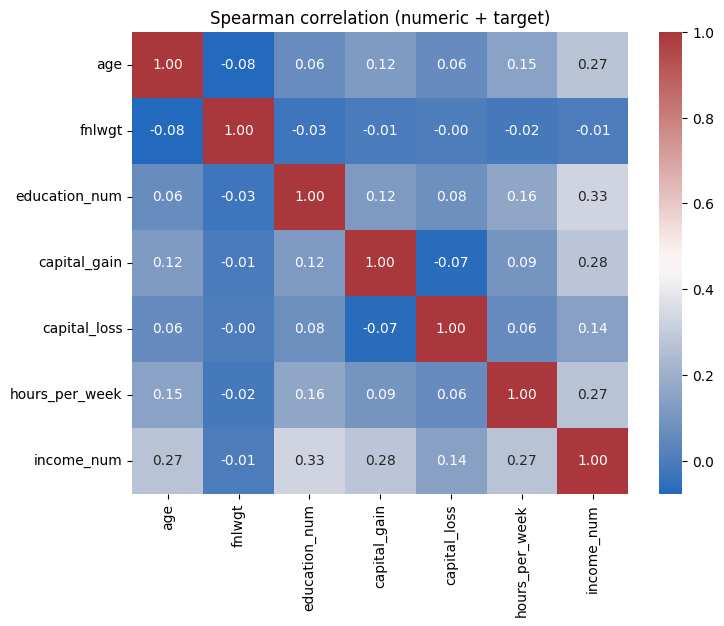


=== Decision Tree ===
Best CV params: {'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 50}
CV best score (ROC AUC): 0.9037

Test metrics:
              precision    recall  f1-score   support

           0     0.8767    0.9517    0.9126      7431
           1     0.7891    0.5744    0.6649      2338

    accuracy                         0.8614      9769
   macro avg     0.8329    0.7631    0.7887      9769
weighted avg     0.8557    0.8614    0.8533      9769

ROC AUC (test): 0.9077


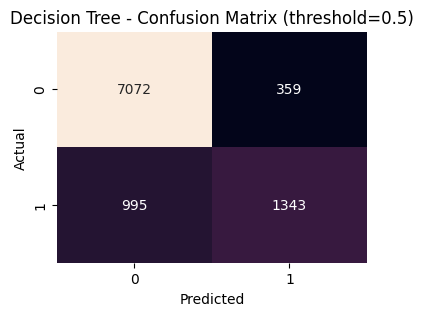

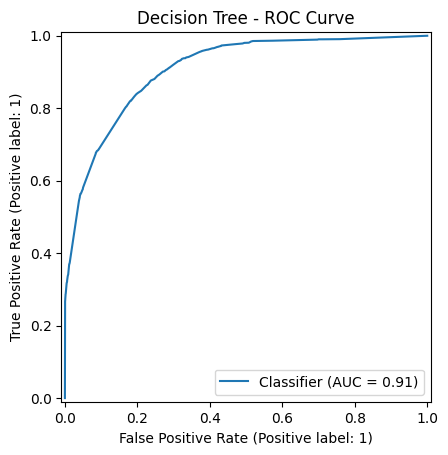

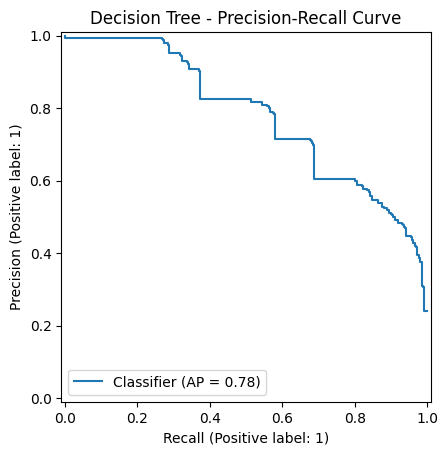

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay, precision_recall_fscore_support)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

np.random.seed(42)
pd.set_option("display.max_columns", 200)

cols = [
    'age','workclass','fnlwgt','education','education_num','marital_status',
    'occupation','relationship','race','sex','capital_gain','capital_loss',
    'hours_per_week','native_country','income'
]

uci_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
uci_test  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

def load_from_uci():
    train = pd.read_csv(uci_train, names=cols, na_values='?', skipinitialspace=True)
    test  = pd.read_csv(uci_test,  names=cols, na_values='?', skipinitialspace=True, skiprows=1)
    df = pd.concat([train, test], ignore_index=True)
    df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()
    return df

def load_from_openml():
    from sklearn.datasets import fetch_openml
    data = fetch_openml('adult', version=2, as_frame=True)
    df = data.frame.rename(columns={'class':'income'})
    return df[cols]

try:
    df = load_from_uci()
except Exception as e:
    print("UCI fetch failed, using OpenML fallback:", e)
    df = load_from_openml()

df.head()


print(df.shape)
print(df['income'].value_counts(dropna=False))
df.info()

for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

df = df.replace('?', np.nan)

df['income_num'] = (df['income'] == '>50K').astype(int)

df.isna().sum().sort_values(ascending=False).head(20)


numeric_features = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
df[numeric_features].describe()


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14,8))
axes = axes.ravel()
for i, col in enumerate(numeric_features):
    df[col].hist(bins=40, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(); plt.show()


categorical_features = [c for c in df.columns if c not in numeric_features + ['income','income_num']]
for cat in ['education','marital_status','occupation','sex','race','workclass']:
    rate = df.groupby(cat)['income_num'].mean().sort_values(ascending=False).head(10)
    print(f"\nIncome rate by {cat} (top 10):\n", rate)

corr_num = df[numeric_features + ['income_num']].corr(method='spearman')  # non-normal-friendly
plt.figure(figsize=(8,6))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap="vlag")
plt.title("Spearman correlation (numeric + target)")
plt.show()


X = df.drop(columns=['income','income_num'])
y = df['income_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features)
    ],
    remainder='drop'
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_search(model, param_grid, scoring='roc_auc'):
    pipe = Pipeline(steps=[('pre', preprocessor),
                          ('model', model)])
    gs = GridSearchCV(
        pipe, param_grid=param_grid, cv=cv, n_jobs=-1, scoring=scoring, verbose=0
    )
    gs.fit(X_train, y_train)
    return gs


def evaluate(gs, name, X_te=X_test, y_te=y_test):
    best = gs.best_estimator_
    proba = best.predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int)

    print(f"\n=== {name} ===")
    print("Best CV params:", gs.best_params_)
    print("CV best score (ROC AUC):", round(gs.best_score_, 4))

    print("\nTest metrics:")
    print(classification_report(y_te, preds, digits=4))
    print("ROC AUC (test):", round(roc_auc_score(y_te, proba), 4))

    cm = confusion_matrix(y_te, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.title(f"{name} - Confusion Matrix (threshold=0.5)")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(y_te, proba)
    plt.title(f"{name} - ROC Curve")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_te, proba)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.show()

    return best


dt = DecisionTreeClassifier(random_state=42)
dt_grid = {
    'model__criterion': ['gini','entropy','log_loss'],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 10, 50],
    'model__min_samples_leaf': [1, 5, 10],
    'model__class_weight': [None, 'balanced']
}
gs_dt = run_search(dt, dt_grid, scoring='roc_auc')
best_dt = evaluate(gs_dt, "Decision Tree")


rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = {
    'model__n_estimators': [300, 600],
    'model__max_depth': [None, 10, 20],
    'model__max_features': ['sqrt','log2'],
    'model__min_samples_leaf': [1, 5],
    'model__class_weight': [None, 'balanced']
}
gs_rf = run_search(rf, rf_grid, scoring='roc_auc')
best_rf = evaluate(gs_rf, "Random Forest")


ada = AdaBoostClassifier(random_state=42)
ada_grid = {
    'model__n_estimators': [200, 400, 800],
    'model__learning_rate': [0.05, 0.1, 0.5, 1.0],
}
gs_ada = run_search(ada, ada_grid, scoring='roc_auc')
best_ada = evaluate(gs_ada, "AdaBoost")


xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_grid = {
    'model__n_estimators': [400, 800],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}
gs_xgb = run_search(xgb, xgb_grid, scoring='roc_auc')
best_xgb = evaluate(gs_xgb, "XGBoost")


results = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "AdaBoost": best_ada,
    "XGBoost": best_xgb
}

plt.figure(figsize=(6,5))
for name, model in results.items():
    proba = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name)
plt.title("ROC Curves - All Models")
plt.show()


plt.figure(figsize=(6,5))
for name, model in results.items():
    proba = model.predict_proba(X_test)[:,1]
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name)
plt.title("Precision-Recall Curves - All Models")
plt.show()


def feature_names_from_pipe(fitted_pipe):
    ohe = fitted_pipe.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
    num_names = numeric_features
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    return num_names + cat_names

def plot_top_importances(fitted_pipe, model_name, topn=20):
    feat_names = feature_names_from_pipe(fitted_pipe)
    importances = fitted_pipe.named_steps['model'].feature_importances_
    s = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(topn)
    ax = s[::-1].plot(kind='barh', figsize=(8,6))
    ax.set_title(f"{model_name} - Top {topn} Feature Importances")
    plt.tight_layout(); plt.show()

plot_top_importances(best_rf, "Random Forest", topn=20)
plot_top_importances(best_xgb, "XGBoost", topn=20)


plt.figure(figsize=(20,10))
feat_names = feature_names_from_pipe(best_dt)
plot_tree(
    best_dt.named_steps['model'],
    feature_names=feat_names,
    class_names=['<=50K','>50K'],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Best Decision Tree (top 3 levels)")
plt.show()


from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1), threshold="median")
pipe_sfm = Pipeline([
    ('pre', preprocessor),
    ('sel', sfm),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param = {'model__n_estimators':[400,800]}
gs_sfm = GridSearchCV(pipe_sfm, param, cv=cv, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
_ = evaluate(gs_sfm, "Random Forest with SelectFromModel")
